# C-MAPSS FD001 — Exploratory Data Analysis

**Goal:** Understand the structure, sensor behavior, and degradation patterns of the C-MAPSS FD001 sub-dataset. Identify informative sensors, characterize the failure horizon, and decide on the modeling frame for Weeks 3–5.

**Dataset:** FD001 — 100 training engines, 100 test engines, single fault mode (HPC degradation), single operating condition.

In [1]:
import sys
from pathlib import Path

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data  # our loader

sns.set_theme(style="whitegrid", context="talk")

SUBSET = "FD001"
train = data.load_train(SUBSET)
test = data.load_test(SUBSET)
rul_truth = data.load_rul(SUBSET)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"RUL shape:   {rul_truth.shape}")
train.head()

Train shape: (20631, 26)
Test shape:  (13096, 26)
RUL shape:   (100, 1)


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
import os
print("Working directory:", os.getcwd())

Working directory: c:\Users\yubyu\OneDrive\Desktop\predictive-maintenance-cmapss\notebooks


In [3]:
print(f"Train: {train['unit'].nunique()} unique engines")
print(f"Test:  {test['unit'].nunique()} unique engines")

Train: 100 unique engines
Test:  100 unique engines


FD001 contains 100 training engines (run to failure) and 100 separate test engines (truncated before failure).

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


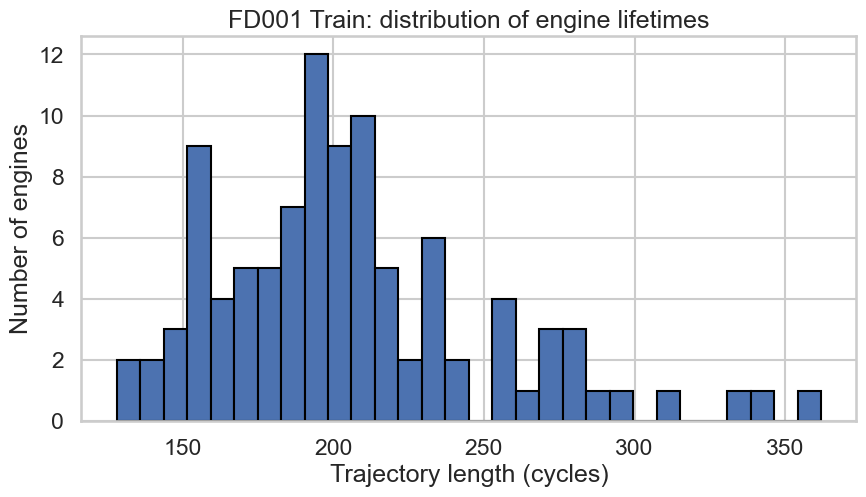

In [4]:
train_traj_lengths = train.groupby("unit")["cycle"].max()
print(train_traj_lengths.describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_traj_lengths, bins=30, edgecolor="black")
ax.set_xlabel("Trajectory length (cycles)")
ax.set_ylabel("Number of engines")
ax.set_title("FD001 Train: distribution of engine lifetimes")
plt.show()

**Takeaway:** Training trajectories range from ~128 to ~362 cycles, with a median around 200 cycles. The distribution is right-skewed — most engines fail in the 150–250 cycle range, with a thinner tail extending to ~360 cycles. This shape is consistent with typical component lifetime distributions in reliability engineering (Weibull-like).

**Implications for modeling:**
- A sliding window of **30–50 cycles** fits comfortably even within the shortest trajectory (128 cycles), leaving room for the model to see degradation patterns.
- The wide spread (>200-cycle range) means engines vary substantially in lifetime, so the model must learn degradation patterns from the *sensor signature*, not from cycle count alone.
- The minimum trajectory (128 cycles) sets a hard upper bound on viable window size for sequence models.

Train trajectories — min: 128, median: 199, max: 362
Test trajectories  — min: 31, median: 134, max: 303

Test trajectory length distribution:
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64


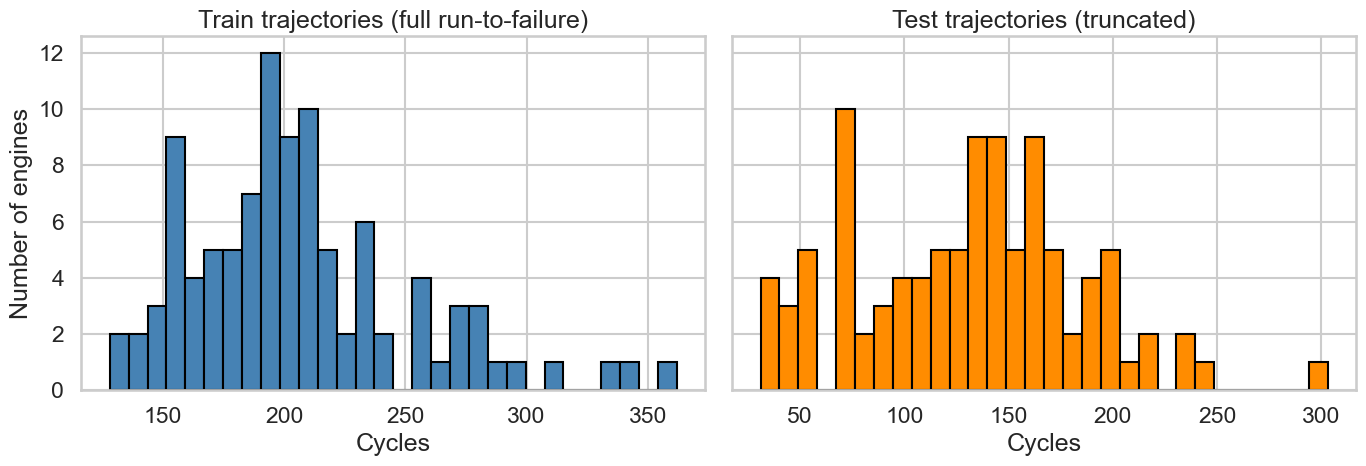

In [6]:
# Compute trajectory lengths
test_traj_lengths = test.groupby("unit")["cycle"].max()

# Print summary stats for both train and test
print(f"Train trajectories — min: {train_traj_lengths.min()}, "
      f"median: {train_traj_lengths.median():.0f}, max: {train_traj_lengths.max()}")
print(f"Test trajectories  — min: {test_traj_lengths.min()}, "
      f"median: {test_traj_lengths.median():.0f}, max: {test_traj_lengths.max()}")
print()
print("Test trajectory length distribution:")
print(test_traj_lengths.describe())

# Then plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(train_traj_lengths, bins=30, edgecolor="black", color="steelblue")
axes[0].set_title("Train trajectories (full run-to-failure)")
axes[0].set_xlabel("Cycles")
axes[0].set_ylabel("Number of engines")
axes[1].hist(test_traj_lengths, bins=30, edgecolor="black", color="darkorange")
axes[1].set_title("Test trajectories (truncated)")
axes[1].set_xlabel("Cycles")
plt.tight_layout()
plt.show()

**Takeaway:** Test trajectories are systematically shorter than training, peaking around 130–160 cycles vs. ~200 for train, and extending down to as little as ~30 cycles. This is the truncation by design — each test engine was stopped at a random point along its (unknown) full lifetime, and the model's job is to predict the remaining life from that partial history.

**Implications for modeling:**
- **The shortest test trajectory (~30 cycles) is the binding constraint on window size**, not the shortest train trajectory. A 30-cycle window is the practical upper bound if every test engine must receive a prediction. Larger windows would require padding, masking, or a fallback strategy for short trajectories.
- **The truncation distribution is realistic.** Some engines were caught early (little degradation visible yet — hard to predict), others late (clear degradation signal — easier). The evaluation set covers the full range of difficulty.
- This is the **core RUL challenge in deployment**: in production, every monitored asset is partway through its trajectory. You never see the full run.

In [7]:
missing_train = train.isna().sum()
missing_test = test.isna().sum()

print("Missing values per column:")
print(f"  Train: {missing_train.sum()} total")
print(f"  Test:  {missing_test.sum()} total")

if missing_train.sum() > 0 or missing_test.sum() > 0:
    print("\nColumns with missing values (train):")
    print(missing_train[missing_train > 0])
else:
    print("\nNo missing values in either set.")

Missing values per column:
  Train: 0 total
  Test:  0 total

No missing values in either set.


**Takeaway:** No missing values in either train or test sets. C-MAPSS is fully simulated and complete by design.

**Why this matters for real-world transfer:** Real plant historian data almost always has gaps — sensor dropouts, network outages, calibration windows where readings are frozen, and historian write failures. A production pipeline would need imputation strategies (forward-fill within short gaps, masking with a "missing" indicator for longer gaps) or an architecture that handles missingness natively (LSTMs with masking layers, GRU-D, etc.). The cleanliness of C-MAPSS lets us focus on the modeling problem, but it underrepresents one of the harder parts of real PHM work.

In [8]:
op_cols = ["op_setting_1", "op_setting_2", "op_setting_3"]
print("Operational settings — summary statistics (train):")
print(train[op_cols].describe())
print()
print("Unique values per setting:")
for col in op_cols:
    n_unique = train[col].nunique()
    print(f"  {col}: {n_unique} unique values")

Operational settings — summary statistics (train):
       op_setting_1  op_setting_2  op_setting_3
count  20631.000000  20631.000000       20631.0
mean      -0.000009      0.000002         100.0
std        0.002187      0.000293           0.0
min       -0.008700     -0.000600         100.0
25%       -0.001500     -0.000200         100.0
50%        0.000000      0.000000         100.0
75%        0.001500      0.000300         100.0
max        0.008700      0.000600         100.0

Unique values per setting:
  op_setting_1: 158 unique values
  op_setting_2: 13 unique values
  op_setting_3: 1 unique values


**Takeaway:** Operational settings are confirmed essentially constant on FD001:

- **`op_setting_3`:** std = 0, exactly 1 unique value (100.0). Literally constant.
- **`op_setting_1`:** std ≈ 0.0022, range ±0.009. Pure noise around a zero setpoint — the 158 unique values reflect floating-point jitter, not real variation.
- **`op_setting_2`:** std ≈ 0.0003, range ±0.0006. Tighter noise, only 13 unique values (likely coarser quantization).

The "single operating condition" label is empirically airtight. **All three columns will be dropped from modeling for FD001.** This is the first concrete feature-engineering decision the EDA produces.

**Structural note for portability:** In FD002 and FD004, these same three columns become highly informative — they encode 6 distinct flight regimes. A model trained on FD001 sees none of that signal, which is one reason FD001 models don't transfer directly to multi-condition sub-datasets without retraining or operating-regime stratification.

In [9]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

# Compute std for each sensor across all training data
sensor_std = train[sensor_cols].std().sort_values()

print("Sensor standard deviations (sorted ascending):")
print(sensor_std)
print()
print(f"Sensors with std == 0: {(sensor_std == 0).sum()}")
print(f"Sensors with std < 0.001: {(sensor_std < 0.001).sum()}")

Sensor standard deviations (sorted ascending):
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

Sensors with std == 0: 4
Sensors with std < 0.001: 6


In [10]:
print("sensor_6 — value distribution:")
print(train["sensor_6"].describe())
print()
print("sensor_6 — unique values (first 20):")
print(sorted(train["sensor_6"].unique())[:20])
print(f"\nTotal unique values: {train['sensor_6'].nunique()}")

sensor_6 — value distribution:
count    20631.000000
mean        21.609803
std          0.001389
min         21.600000
25%         21.610000
50%         21.610000
75%         21.610000
max         21.610000
Name: sensor_6, dtype: float64

sensor_6 — unique values (first 20):
[np.float64(21.6), np.float64(21.61)]

Total unique values: 2


**Takeaway:** Of the 21 sensors, **7 are non-informative** and will be dropped from modeling:

- **Numerically constant (std = 0):** sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19 — six sensors whose readings never change across any engine or cycle.
- **Quantization-only variance:** sensor_6 — only two unique values (21.60 and 21.61), separated by a single quantization step. Std = 0.00139, but the variation is a numerical artifact, not a physical signal.

**Drop list (final):** sensor_1, sensor_5, sensor_6, sensor_10, sensor_16, sensor_18, sensor_19.

**Retained sensors (14):** sensor_2, sensor_3, sensor_4, sensor_7, sensor_8, sensor_9, sensor_11, sensor_12, sensor_13, sensor_14, sensor_15, sensor_17, sensor_20, sensor_21. These have meaningful variance and will be carried into feature engineering in Week 3.

**Cross-check:** This drop list matches the convention used in Asif et al. (2022) and other C-MAPSS papers, which independently identify the same 14 informative sensors on FD001. Arrived at here from data inspection rather than by following the literature.

In [11]:
# Codify the drop / keep lists for reuse throughout the notebook
DROP_SENSORS = ["sensor_1", "sensor_5", "sensor_6", "sensor_10",
                "sensor_16", "sensor_18", "sensor_19"]
KEEP_SENSORS = [s for s in sensor_cols if s not in DROP_SENSORS]

print(f"Dropping {len(DROP_SENSORS)} sensors: {DROP_SENSORS}")
print(f"Retaining {len(KEEP_SENSORS)} sensors: {KEEP_SENSORS}")

Dropping 7 sensors: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Retaining 14 sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


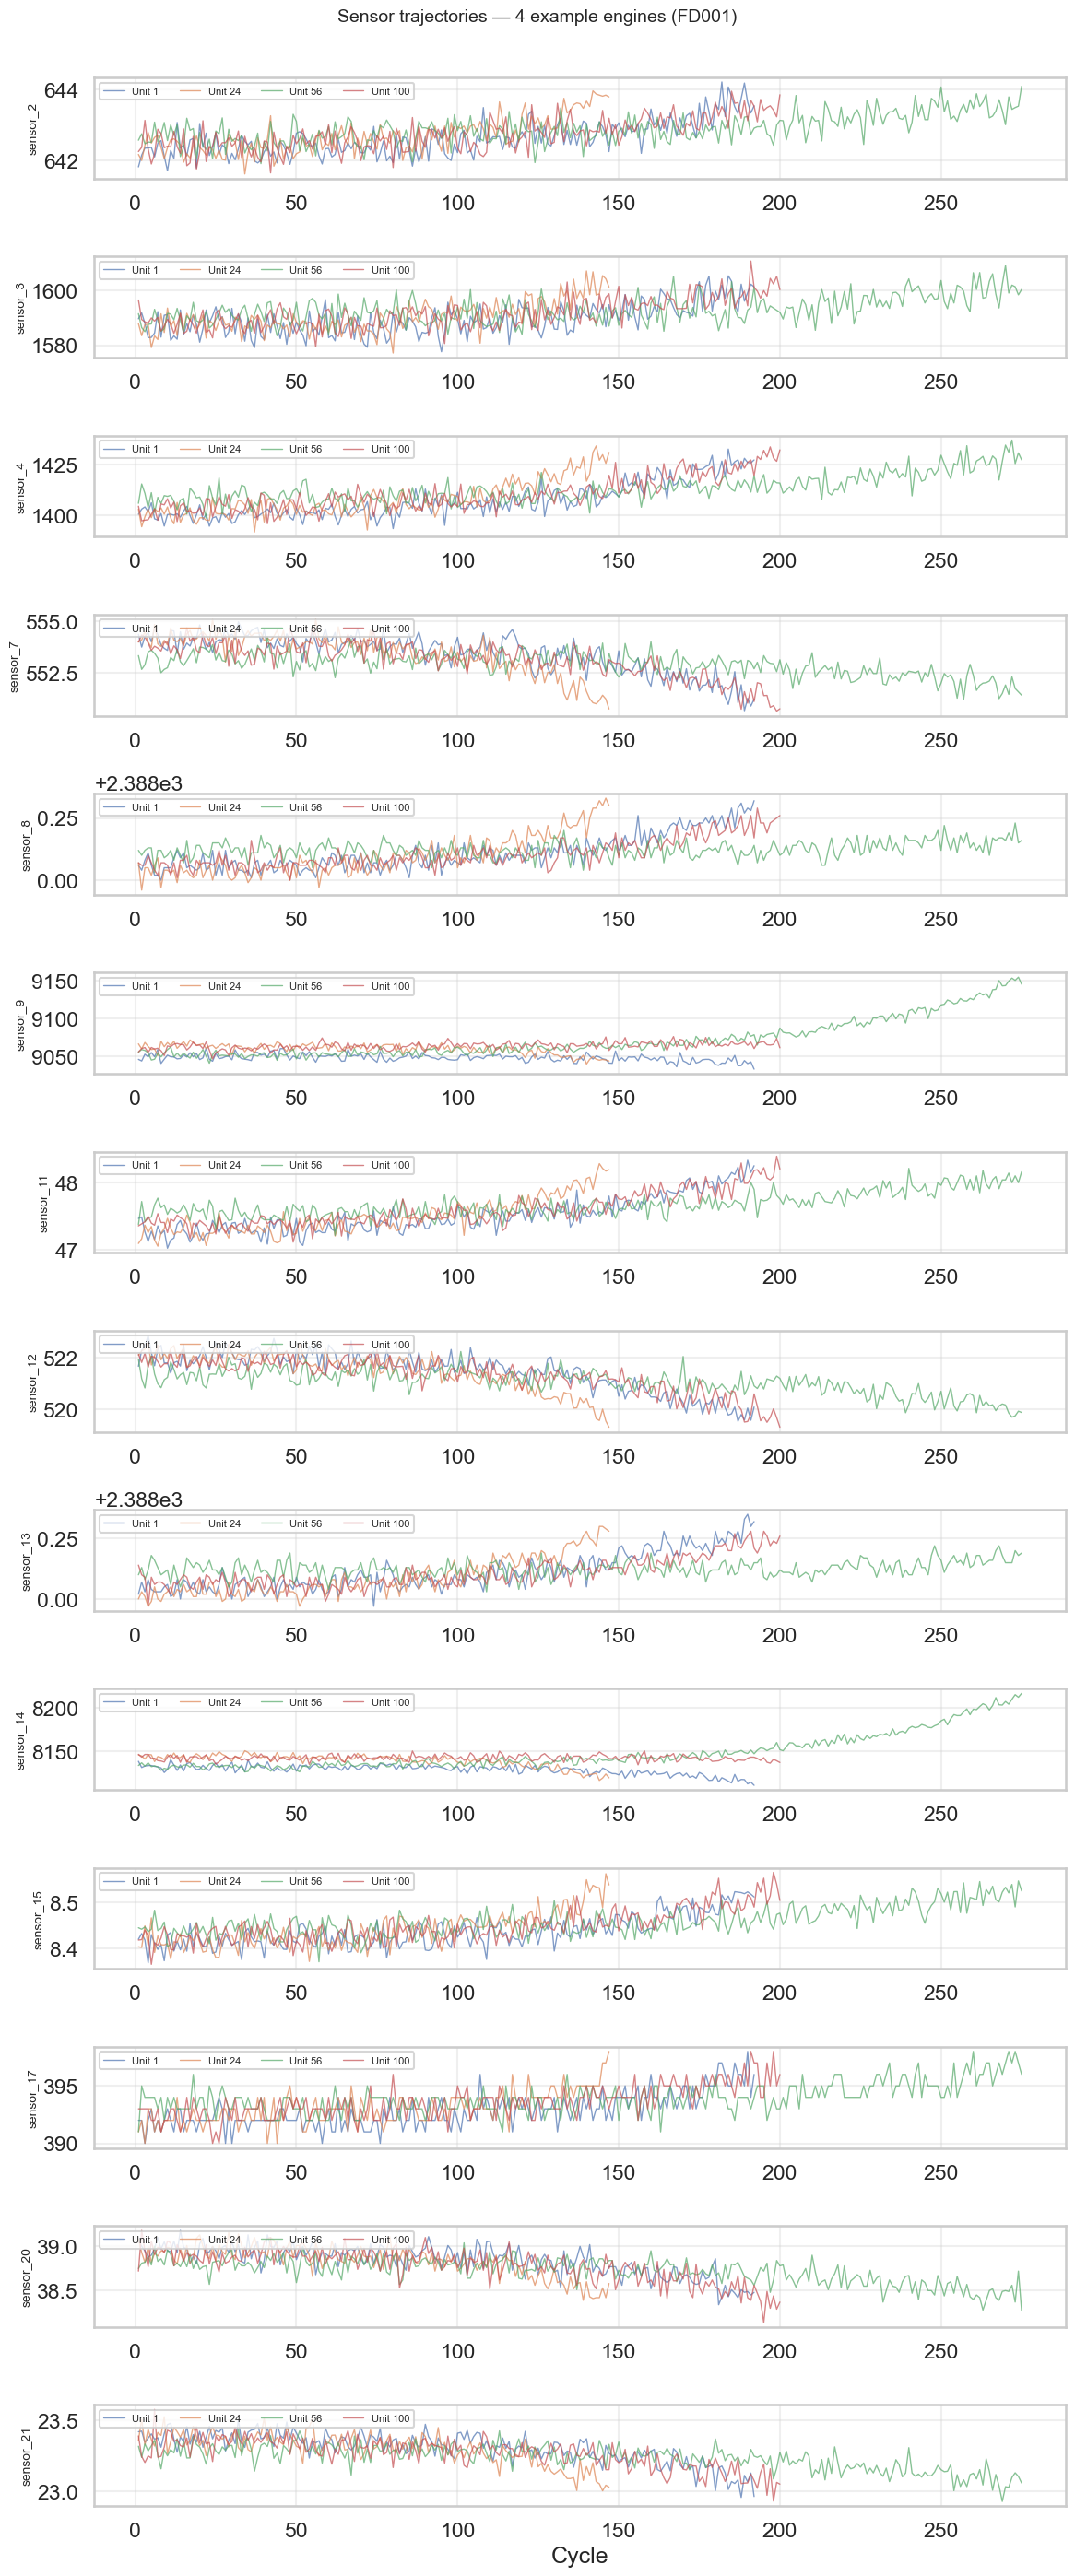

In [12]:
# Pick 4 engines spanning short/medium/long trajectories
engines_to_plot = [1, 24, 56, 100]

fig, axes = plt.subplots(len(KEEP_SENSORS), 1,
                          figsize=(12, 2 * len(KEEP_SENSORS)),
                          sharex=False)

for ax, sensor in zip(axes, KEEP_SENSORS):
    for unit_id in engines_to_plot:
        engine_data = train[train["unit"] == unit_id]
        ax.plot(engine_data["cycle"], engine_data[sensor],
                label=f"Unit {unit_id}", alpha=0.7, linewidth=1)
    ax.set_ylabel(sensor, fontsize=10)
    ax.legend(loc="upper left", fontsize=8, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Cycle")
fig.suptitle("Sensor trajectories — 4 example engines (FD001)",
             fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

**Takeaway:** All 14 retained sensors show meaningful trends. The sensors group into three behavioral patterns:

- **Rising toward failure (8 sensors):** sensor_2, sensor_3, sensor_4 (high values — likely temperatures), sensor_8, sensor_11, sensor_13, sensor_15, sensor_17. These trend upward consistently across all four engines, suggesting thermal/efficiency degradation.
- **Falling toward failure (4 sensors):** sensor_7, sensor_12, sensor_20, sensor_21. These trend downward — likely pressure or efficiency-related quantities declining as the engine degrades.
- **Mixed behavior (2 sensors):** sensor_9, sensor_14. The long-lived engine (Unit 56) drifts upward on these, while shorter-lived engines drift downward or stay flat. Possible bidirectional degradation mode or interaction with the secondary fault mode — flagging for review when extending to FD003 (2 fault modes).

**Key observation — the flat-then-degrade pattern:** On the clearest sensors (sensor_2, sensor_4, sensor_11), trajectories are essentially flat for the first ~100–125 cycles of life, then begin trending toward failure. This is direct empirical justification for clipping the RUL target in modeling — above ~125 cycles remaining, the sensors carry no degradation signal, so forcing the model to predict that range trains it on noise. **A piecewise-linear RUL cap at 125 cycles is supported by this evidence** and aligns with the C-MAPSS literature.

**Implication for failure mechanism:** Unit 56 (long-lived, ~280 cycles) reaches the same sensor signatures at its late cycles that shorter-lived engines reach at theirs. Failure is determined by degradation level, not by elapsed cycle count — meaning the model must learn the sensor *signature* of imminent failure, not just count cycles. This is the core reason this dataset has predictive value.

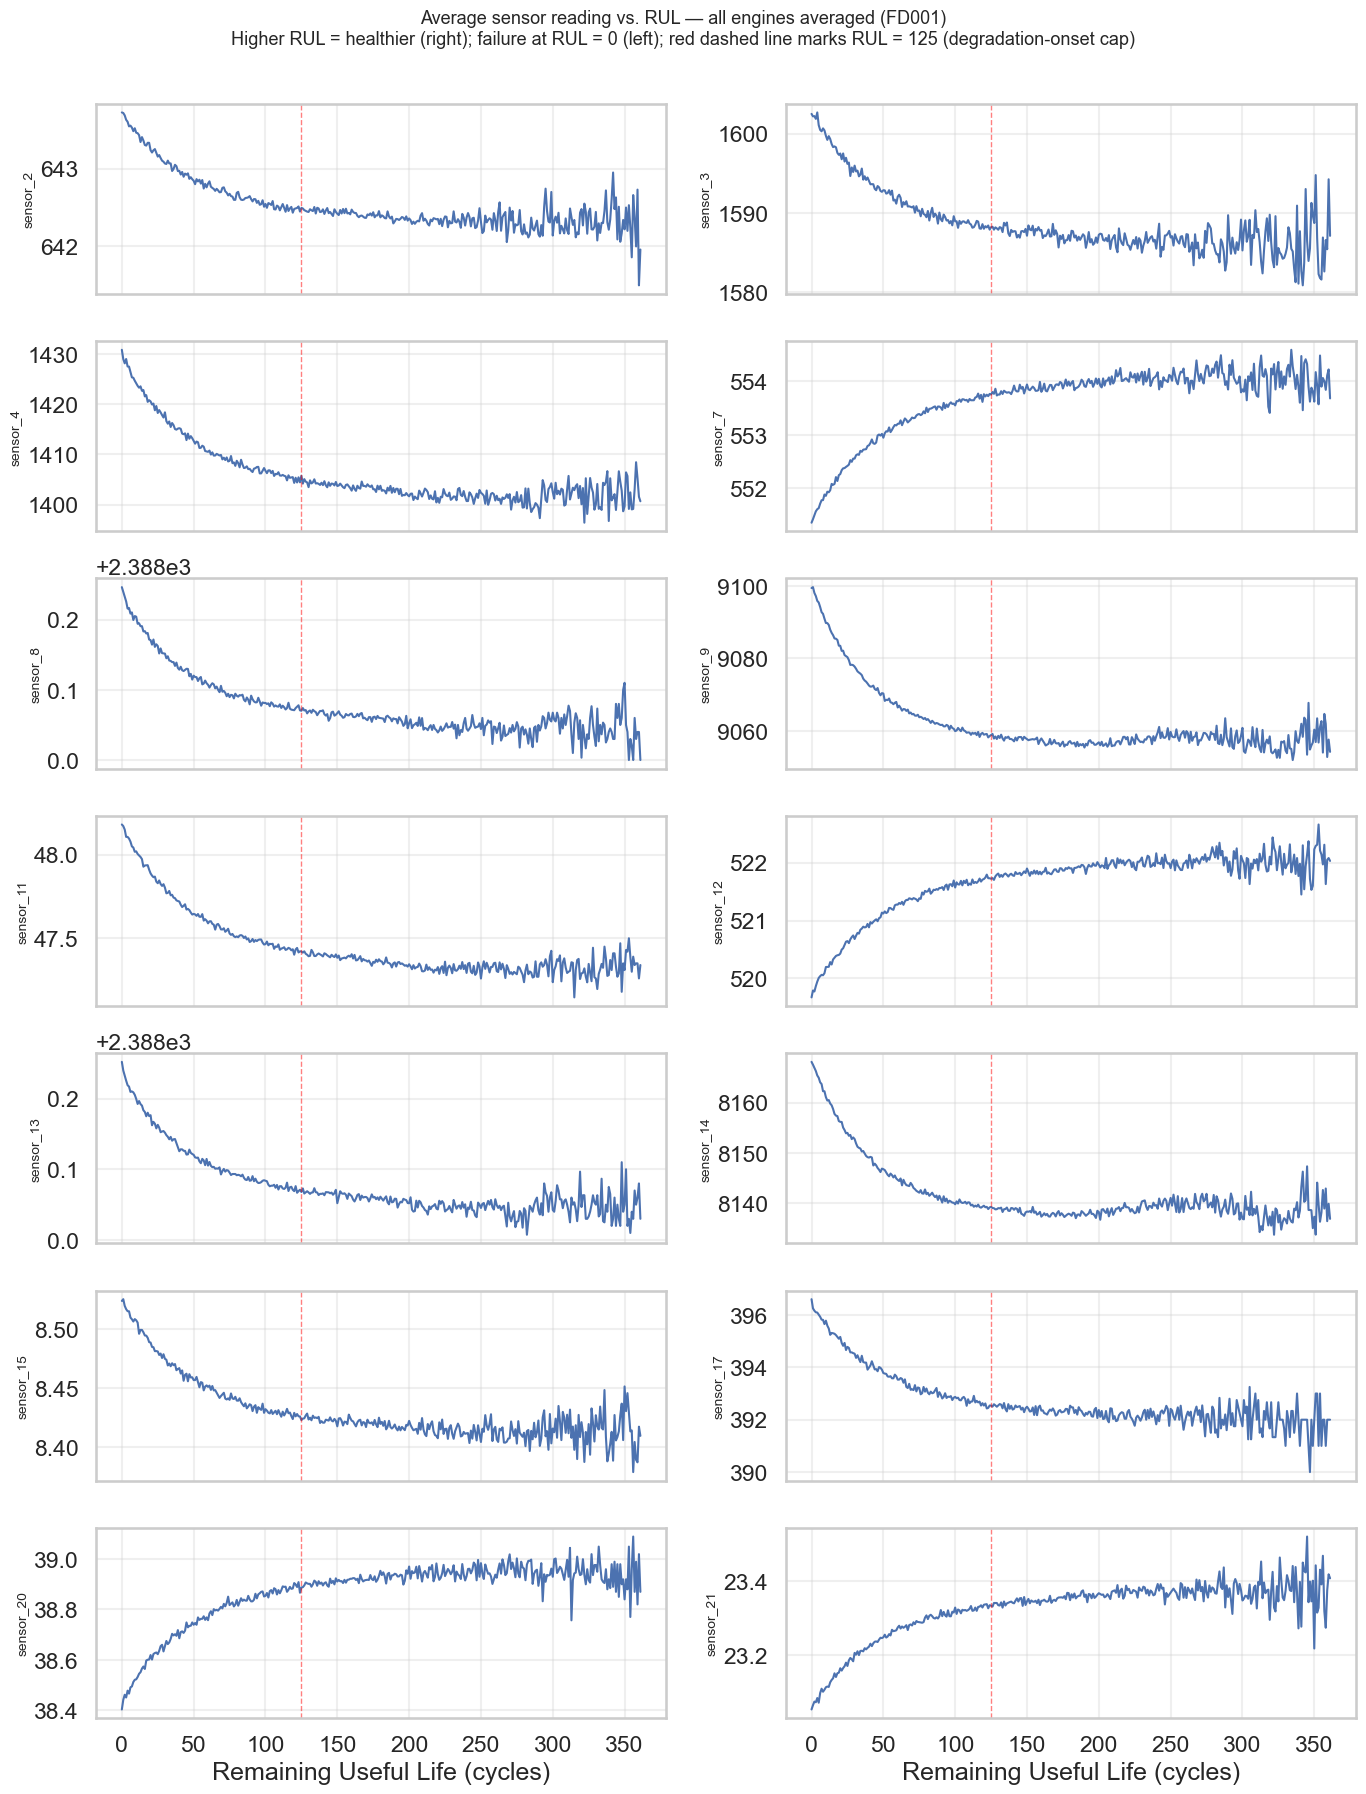

In [15]:
# Compute RUL for every row in training data
train = train.copy()
max_cycle_per_unit = train.groupby("unit")["cycle"].transform("max")
train["rul"] = max_cycle_per_unit - train["cycle"]

# Group by RUL and compute the mean sensor reading at each RUL value
# This averages across all engines, revealing the average degradation curve
rul_grouped = train.groupby("rul")[KEEP_SENSORS].mean().reset_index()

# Plot each retained sensor against RUL (reversed so time flows left-to-right)
fig, axes = plt.subplots(7, 2, figsize=(14, 18), sharex=True)
axes = axes.flatten()

for ax, sensor in zip(axes, KEEP_SENSORS):
    ax.plot(rul_grouped["rul"], rul_grouped[sensor], linewidth=1.5)
    ax.axvline(x=125, color="red", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_ylabel(sensor, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Remaining Useful Life (cycles)")
axes[-2].set_xlabel("Remaining Useful Life (cycles)")
fig.suptitle("Average sensor reading vs. RUL — all engines averaged (FD001)\n"
             "Higher RUL = healthier (right); failure at RUL = 0 (left); "
             "red dashed line marks RUL = 125 (degradation-onset cap)",
             fontsize=13, y=1.001)
plt.tight_layout()
plt.show()

**Takeaway: This is the strongest visualization of FD001's degradation structure.** Averaging sensor readings across all engines at each RUL value reveals each sensor's "population-average path to failure" — and the picture is remarkably clean.

**Sensor categorization (refined from population averages):**

- **Rising toward failure (10 sensors):** sensor_2, sensor_3, sensor_4, sensor_8, sensor_9, sensor_11, sensor_13, sensor_14, sensor_15, sensor_17. The averaged view resolves the apparent ambiguity in sensor_9 and sensor_14 from the individual-engine plot — both clearly rise as failure approaches, but per-engine noise obscured the trend.
- **Falling toward failure (4 sensors):** sensor_7, sensor_12, sensor_20, sensor_21.

**The flat-then-degrade pattern, made visible:** Every degrading sensor shows three distinct regimes:
- **RUL > ~125 cycles (right of red line):** essentially flat — no learnable signal about how far away failure is.
- **RUL ≈ 125–50 cycles:** gradual onset of monotonic degradation.
- **RUL < 50 cycles:** steep, unmistakable change.

**The red dashed line in each panel marks RUL = 125** — the empirical cut-off where degradation signal emerges. This is the data-driven justification for clipping the RUL target at 125 cycles in modeling. Above 125, sensors carry no information distinguishing one high RUL value from another; forcing the model to predict in that range trains it on noise.

**A note on right-tail noise:** The noisy oscillations above RUL ≈ 300 reflect small-sample averaging — only the longest-lived engines (e.g., Unit 56 at ~280 cycles) produce data at high RUL values, so the mean there is averaged over very few observations. Not a real signal pattern.

**Why this plot matters:** Population-averaged sensor-vs-RUL is the most informative visualization for an RUL prediction problem. It tells you (a) which sensors carry signal and in which direction, (b) when in an engine's life that signal becomes detectable, and (c) where to set the RUL cap. All three answers are needed before writing any model code.

## Failure Horizon Summary

**Question:** How early in an engine's life does degradation become detectable, and how early can a model meaningfully predict RUL?

**Answer:** Roughly **125 cycles before failure**.

- **Detection of degradation onset (Task 4c):** Population-averaged sensor trajectories are flat for RUL > ~125 cycles. Below that, monotonic trends emerge across multiple sensors. This is when the model has signal to work with.
- **Practical prediction horizon:** With a 30-cycle sliding window (constrained by the shortest test trajectory), the model can produce stable predictions starting roughly 125 cycles before failure — i.e., it should reliably distinguish "degrading" from "healthy" with at least ~125 cycles of operating buffer.
- **Modeling implication:** Capping the regression target at RUL = 125 (the piecewise-linear approach) prevents the model from being penalized for inability to distinguish unobservable differences (RUL = 200 vs. 300). The same model still predicts low RUL values accurately, which is the operationally important range.

**This is the empirical answer to "how much warning does the model give you?" — about 4 months of operating buffer at typical commercial aviation usage rates, or proportional buffer for industrial pumps and compressors if the methodology were transferred.**

## Modeling Decisions (Final)

Based on the EDA above, the following decisions are locked in for Weeks 3–5:

1. **Framing:** Regression on RUL (continuous target).
2. **RUL target transformation:** Piecewise-linear with cap at 125 cycles. RUL values above 125 are clamped to 125; below 125 they are used as-is. Empirically justified by Task 4c (sensors are flat for RUL > 125, so no useful prediction signal exists there).
3. **Features for modeling:** 14 retained sensors (sensor_2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21). The 3 operational settings and 7 non-informative sensors (1, 5, 6, 10, 16, 18, 19) are dropped.
4. **Window size for sequence models:** 30 cycles. Constrained by the shortest test trajectory (~30 cycles) to ensure every test engine gets a prediction without padding workarounds.
5. **Primary metric:** RMSE on RUL.
6. **Secondary metric:** NASA Score function (asymmetric, penalizes late predictions exponentially).
7. **Validation strategy:** Hold out 20% of training engines for validation. Cross-validation will use **engine-level splits** — never split an engine's trajectory across train and validation, since that would leak future information.